In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ( accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix, classification_report, roc_curve, precision_recall_curve )

In [41]:
df = pd.read_csv("creditcard.csv")
print("\nDataset shape:")
print(df.shape)
print(df.head())


Dataset shape:
(284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

   

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [43]:
print(df.isnull().sum().sum())

0


In [44]:
print(df["Class"].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


In [45]:
print("\nClass percentage:")
print( df["Class"].value_counts(normalize=True) * 100 )


Class percentage:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


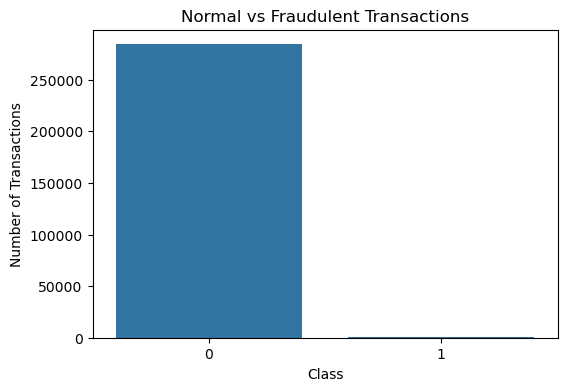

In [46]:
plt.figure(figsize=(6, 4))
sns.countplot( x="Class", data=df )
plt.title("Normal vs Fraudulent Transactions")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")
plt.show()

In [47]:
X = df.drop("Class", axis=1)
y = df["Class"]
print("\nFeatures shape:")
print(X.shape)
print("\nTarget shape:")
print(y.shape)


Features shape:
(284807, 30)

Target shape:
(284807,)


In [48]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42, stratify=y )

In [49]:
print("\nTraining data shape:")
print(X_train.shape)
print("\nTesting data shape:")
print(X_test.shape)
print("\nTraining class distribution:")
print(y_train.value_counts())
print("\nTesting class distribution:")
print(y_test.value_counts())


Training data shape:
(227845, 30)

Testing data shape:
(56962, 30)

Training class distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Testing class distribution:
Class
0    56864
1       98
Name: count, dtype: int64


In [50]:
scaler = StandardScaler()
X_train = X_train.copy()
X_test = X_test.copy()
X_train["Time"] = scaler.fit_transform( X_train[["Time"]] )
X_test["Time"] = scaler.transform( X_test[["Time"]] )
X_train["Amount"] = scaler.fit_transform( X_train[["Amount"]] )
X_test["Amount"] = scaler.transform( X_test[["Amount"]] )

In [51]:
normal_transactions = (y_train == 0).sum()
fraud_transactions = (y_train == 1).sum()

In [52]:
scale_pos_weight = ( normal_transactions / fraud_transactions )

In [53]:
print("\nNormal transactions:", normal_transactions)
print("Fraud transactions:", fraud_transactions)


Normal transactions: 227451
Fraud transactions: 394


In [54]:
print( "Scale positive weight:", round(scale_pos_weight, 2) )

Scale positive weight: 577.29


In [55]:
model = XGBClassifier( n_estimators=200, max_depth=5, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, scale_pos_weight=scale_pos_weight, objective="binary:logistic", eval_metric="logloss", random_state=42, n_jobs=-1 )

In [56]:
print("\nTraining XGBoost model...")
model.fit( X_train, y_train )
print("Model training completed.")


Training XGBoost model...
Model training completed.


In [57]:
y_pred = model.predict(X_test)

In [58]:
y_probability = model.predict_proba(X_test)[:, 1]

In [59]:
accuracy = accuracy_score( y_test, y_pred )

In [60]:
precision = precision_score( y_test, y_pred, zero_division=0 )

In [61]:
recall = recall_score( y_test, y_pred, zero_division=0 )

In [62]:
f1 = f1_score( y_test, y_pred, zero_division=0 )

In [63]:
roc_auc = roc_auc_score( y_test, y_probability )

In [64]:
pr_auc = average_precision_score( y_test, y_probability )

In [65]:
print("\n======================================")
print("XGBOOST MODEL RESULTS")
print("======================================")
print("Accuracy :", round(accuracy, 4)*100)
print("Precision:", round(precision, 4))
print("Recall :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC :", round(roc_auc, 4))
print("PR-AUC :", round(pr_auc, 4))


XGBOOST MODEL RESULTS
Accuracy : 99.87
Precision: 0.5822
Recall : 0.8673
F1 Score : 0.6967
ROC-AUC : 0.9842
PR-AUC : 0.8644


In [66]:
print("\nClassification Report:")
print(classification_report( y_test, y_pred, target_names=[ "Normal", "Fraud" ], zero_division=0 ))


Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.58      0.87      0.70        98

    accuracy                           1.00     56962
   macro avg       0.79      0.93      0.85     56962
weighted avg       1.00      1.00      1.00     56962



In [67]:
cm = confusion_matrix( y_test, y_pred )

In [68]:
print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[56803    61]
 [   13    85]]


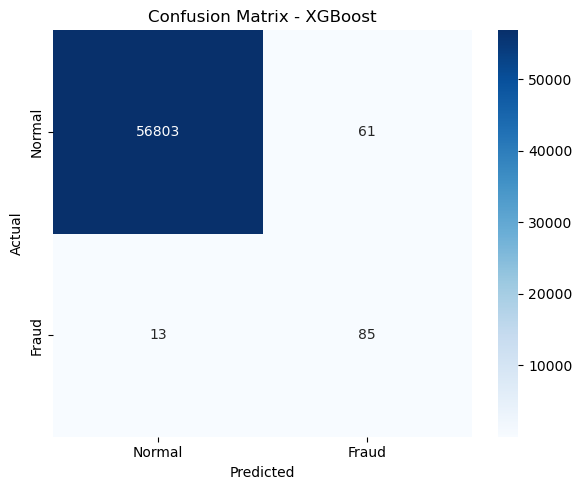

In [69]:
plt.figure(figsize=(6, 5))
sns.heatmap( cm, annot=True, fmt="d", cmap="Blues", xticklabels=[ "Normal", "Fraud" ], yticklabels=[ "Normal", "Fraud" ] )
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.tight_layout()
plt.show()

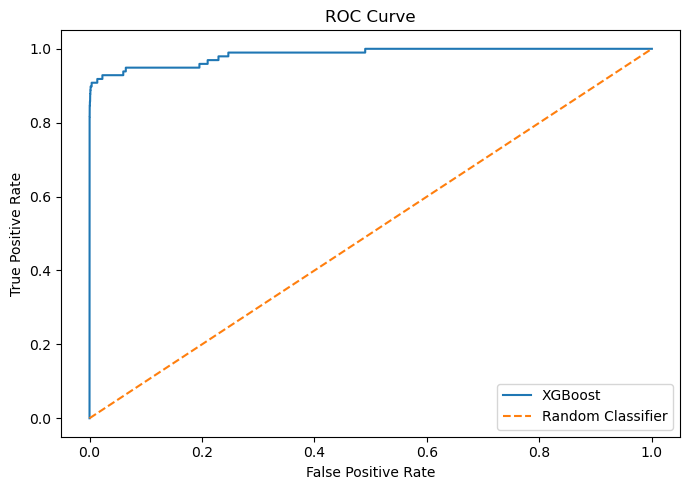

In [70]:
fpr, tpr, thresholds = roc_curve( y_test, y_probability )
plt.figure(figsize=(7, 5))
plt.plot( fpr, tpr, label="XGBoost" )
plt.plot( [0, 1], [0, 1], linestyle="--", label="Random Classifier" )
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [71]:
precision_values, recall_values, thresholds = ( precision_recall_curve( y_test, y_probability ) )

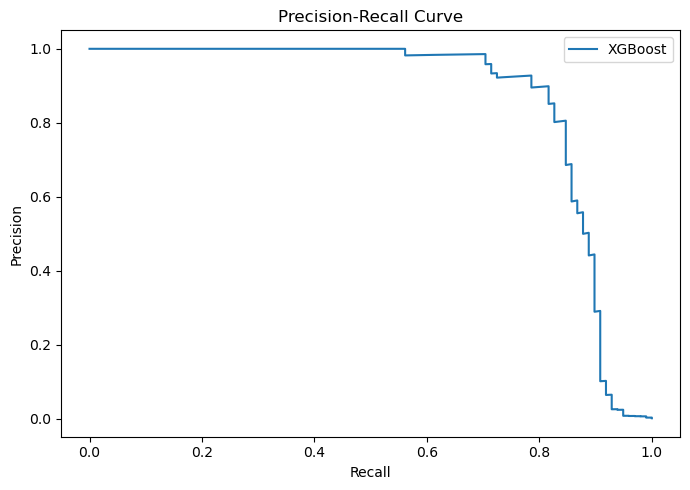

In [72]:
plt.figure(figsize=(7, 5))
plt.plot( recall_values, precision_values, label="XGBoost" )
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.tight_layout()
plt.show()